# Step 01 — Setup and class prototypes

**A Computer Vision Project — *Flow Matching as a Layer*** · Stage 2
University of Haifa

---

## Purpose

Prepare everything the Flow Matching layer needs, and **prove the Stage 1 prototype baseline
is reproduced exactly** before anything is built on top of it.

Stage 2 inserts a learned transport step between the frozen feature $z$ and the prototype
classifier. That comparison is only meaningful if the starting point is bit-for-bit the same
baseline Stage 1 reported — so this notebook rebuilds all 21 prototype sets from the cached
features and checks every resulting accuracy against `Stage_1/results/prototype_runs.csv`.

## Nothing is re-extracted or retrained here

| | |
| --- | --- |
| Encoders run | **none** — no forward passes, no GPU work |
| Datasets loaded | **none** — no images are read |
| Stage 1 files touched | **read-only** |

The two inputs are Stage 1 artefacts that already exist on disk:

- `Stage_1/features/*.pt` — the 9 cached feature files (encoder outputs, computed once)
- `Stage_1/results/prototype_runs.csv` — the baseline accuracies to verify against

Prototype construction is deterministic given a fixed subset, so rebuilding them is
arithmetic on tensors already in memory — seconds, not minutes.

## Sections

| # | Section |
| --- | --- |
| 1 | Setup and environment |
| 2 | Stage 1 feature cache — read-only inventory |
| 3 | Feature geometry — why the flow needs L2-normalized inputs |
| 4 | Build the prototypes (21 sets) |
| 5 | Verification against Stage 1 |
| 6 | Save Stage 2 artefacts |
| 7 | Manifest |

## 1 · Setup and environment

`cvlab` (Stage 1) supplies the feature loader, the k-shot sampler and the prototype maths;
`cvlabfm` (Stage 2) supplies only the paths, so artefacts land under `Stage_2/`. Sharing
Stage 1's implementations rather than reimplementing them is what keeps the baseline and the
Stage 2 comparison exactly aligned.

In [1]:
from __future__ import annotations

import platform
import sys
import time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

import cvlab
from cvlab.data import make_kshot_subset
from cvlab.features import feature_path, load_features
from cvlab.plotting import ArtifactWriter, apply_style
from cvlab.prototypes import compute_prototypes, l2_normalize, run_prototype_classifier

import cvlabfm
from cvlabfm.paths import RESULTS_ROOT, STAGE1_FEATURES, STAGE1_RESULTS, describe, step_dirs

apply_style()
art = ArtifactWriter(*step_dirs("01_setup_prototypes"))
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

# The Stage 1 experimental grid, reused verbatim.
COMBOS: list[tuple[str, str]] = [
    ("resnet18", "DTD"),
    ("resnet18", "FGVC-Aircraft"),
    ("dinov2", "FGVC-Aircraft"),
]
K_SETTINGS: list[int | str] = [5, 10, "full"]
SEEDS: list[int] = [0, 1, 2]
SPLITS: list[str] = ["train", "val", "test"]

print(describe())

Stage_2 root          : C:\Users\youse\Project in Computer Vision\ProjectInComputerVision\Stage_2  [ok]
Work root             : C:\Users\youse\Project in Computer Vision\ProjectInComputerVision\Stage_2\Work  [ok]
Results (Stage 2)     : C:\Users\youse\Project in Computer Vision\ProjectInComputerVision\Stage_2\results  [ok]
Docs                  : C:\Users\youse\Project in Computer Vision\ProjectInComputerVision\Stage_2\docs  [ok]
Stage_1 root          : C:\Users\youse\Project in Computer Vision\ProjectInComputerVision\Stage_1  [ok]
Stage_1 feature cache : C:\Users\youse\Project in Computer Vision\ProjectInComputerVision\Stage_1\features  [ok]
Stage_1 results       : C:\Users\youse\Project in Computer Vision\ProjectInComputerVision\Stage_1\results  [ok]


In [2]:
environment = pd.DataFrame([
    {"item": "python",      "value": sys.version.split()[0]},
    {"item": "platform",    "value": f"{platform.system()} {platform.release()}"},
    {"item": "torch",       "value": torch.__version__},
    {"item": "numpy",       "value": np.__version__},
    {"item": "pandas",      "value": pd.__version__},
    {"item": "cvlab",       "value": cvlab.__version__ if hasattr(cvlab, "__version__") else "editable"},
    {"item": "cvlabfm",     "value": cvlabfm.__version__},
    {"item": "device used", "value": "cpu (no encoder runs in this step)"},
])
art.table(environment, "environment")
environment

  saved table -> tables/environment.csv  (8 rows)


,item,value
0,python,3.10.11
1,platform,Windows 10
2,torch,2.6.0+cu124
3,numpy,2.2.6
4,pandas,2.3.3
5,cvlab,1.0.0
6,cvlabfm,1.0.0
7,device used,cpu (no encoder runs in this step)


## 2 · Stage 1 feature cache — read-only inventory

Load all 9 cached bundles and record what is actually on disk. This is the only place Stage 2
reads feature data; every later step works from the prototypes and subsets derived here.

The `crop_banner` column is carried through from Stage 1's provenance metadata — a reminder
that the Aircraft features were extracted from banner-cropped images, and that Stage 2
inherits that decision rather than revisiting it.

In [3]:
features: dict[tuple[str, str, str], object] = {}
inventory_rows: list[dict] = []

load_start = time.perf_counter()
for enc, ds in COMBOS:
    for split in SPLITS:
        bundle = load_features(enc, ds, split)
        features[(enc, ds, split)] = bundle
        path = feature_path(enc, ds, split)
        inventory_rows.append({
            "encoder": enc,
            "dataset": ds,
            "split": split,
            "n_images": len(bundle),
            "dim": bundle.dim,
            "n_classes": bundle.n_classes,
            "crop_banner": bundle.meta.get("crop_banner", "?"),
            "file": path.name,
            "size_MB": round(path.stat().st_size / 1024**2, 2),
        })

inventory = pd.DataFrame(inventory_rows)
print(f"loaded {len(inventory)} cache files in {time.perf_counter() - load_start:.2f}s "
      f"({inventory.n_images.sum():,} feature vectors, no encoder was run)")
art.table(inventory, "feature_inventory")
inventory

loaded 9 cache files in 0.03s (25,640 feature vectors, no encoder was run)
  saved table -> tables/feature_inventory.csv  (9 rows)


,encoder,dataset,split,n_images,dim,n_classes,crop_banner,file,size_MB
0,resnet18,DTD,train,1880,512,47,False,resnet18__dtd__train.pt,3.69
1,resnet18,DTD,val,1880,512,47,False,resnet18__dtd__val.pt,3.69
2,resnet18,DTD,test,1880,512,47,False,resnet18__dtd__test.pt,3.69
3,resnet18,FGVC-Aircraft,train,3334,512,100,True,resnet18__fgvc_aircraft__train.pt,6.54
4,resnet18,FGVC-Aircraft,val,3333,512,100,True,resnet18__fgvc_aircraft__val.pt,6.54
5,resnet18,FGVC-Aircraft,test,3333,512,100,True,resnet18__fgvc_aircraft__test.pt,6.54
6,dinov2,FGVC-Aircraft,train,3334,384,100,True,dinov2__fgvc_aircraft__train.pt,4.91
7,dinov2,FGVC-Aircraft,val,3333,384,100,True,dinov2__fgvc_aircraft__val.pt,4.91
8,dinov2,FGVC-Aircraft,test,3333,384,100,True,dinov2__fgvc_aircraft__test.pt,4.91


In [4]:
# Integrity: labels must be in range, features finite, and the three splits disjoint in size
# terms must match what Stage 1 recorded. A silent shape or dtype drift here would poison
# every FM result downstream, so it is asserted rather than eyeballed.
for (enc, ds, split), bundle in features.items():
    assert bundle.features.dtype == torch.float32, f"{enc}/{ds}/{split}: not float32"
    assert bundle.labels.dtype == torch.int64, f"{enc}/{ds}/{split}: labels not int64"
    assert torch.isfinite(bundle.features).all(), f"{enc}/{ds}/{split}: non-finite features"
    assert int(bundle.labels.min()) >= 0 and int(bundle.labels.max()) < bundle.n_classes, \
        f"{enc}/{ds}/{split}: labels out of range"
    assert len(bundle.features) == len(bundle.labels), f"{enc}/{ds}/{split}: length mismatch"

print("all 9 bundles pass: dtype, finiteness, label range, length")

all 9 bundles pass: dtype, finiteness, label range, length


## 3 · Feature geometry — why the flow needs L2-normalized inputs

This is the one design decision Stage 2 has to make before writing any training code.

Class prototypes are **unit-norm by construction** (`compute_prototypes` re-normalizes after
averaging). Raw encoder features are not — Stage 1 measured norms of roughly 24–50. The flow
target is

$$u_i = p_{y_i} - z_i$$

so if $\lVert z_i \rVert \approx 30$ and $\lVert p_{y_i} \rVert = 1$, then $u_i \approx -z_i$:
the prototype contributes almost nothing to the direction the network is asked to predict.
The velocity network would spend its capacity learning *"shrink toward the origin"* rather
than *"move toward the right class"*.

The measurement below quantifies exactly that, via the **alignment between the target and
"undo the feature"**:

$$a = \cos\!\big(u_i,\; -z_i\big)$$

$a \to 1$ means the supervised direction is indistinguishable from cancelling the feature —
it carries no class information at all. A value clearly below 1 means the prototype term
genuinely shapes the target.

The fix is to L2-normalize $z$ so both endpoints live on the same unit sphere — which is
**not** a deviation from Stage 1, since `cvlab.prototypes` already normalizes before
averaging and before the cosine rule. Cosine classification is scale-invariant, so the
reported accuracy is unaffected.

In [5]:
geometry_rows: list[dict] = []

for enc, ds in COMBOS:
    tr = features[(enc, ds, "train")]
    # Full-data prototypes are enough to characterise the geometry.
    protos = compute_prototypes(tr.features, tr.labels, tr.n_classes)

    z_raw = tr.features
    z_hat = l2_normalize(z_raw)
    p_of_i = protos[tr.labels]                      # each example's own class prototype

    u_raw = p_of_i - z_raw
    u_hat = p_of_i - z_hat

    # How much of the supervised direction is simply "undo the feature"?
    # cos(u, -z) -> 1 means the target carries no class information.
    align_raw = torch.nn.functional.cosine_similarity(u_raw, -z_raw, dim=1).mean().item()
    align_hat = torch.nn.functional.cosine_similarity(u_hat, -z_hat, dim=1).mean().item()

    geometry_rows.append({
        "encoder": enc,
        "dataset": ds,
        "dim": tr.dim,
        "feat_norm_raw_mean": round(z_raw.norm(dim=1).mean().item(), 2),
        "feat_norm_raw_std": round(z_raw.norm(dim=1).std().item(), 2),
        "proto_norm": round(protos.norm(dim=1).mean().item(), 4),
        "target_norm_raw": round(u_raw.norm(dim=1).mean().item(), 2),
        "target_norm_norm": round(u_hat.norm(dim=1).mean().item(), 3),
        "align_raw": round(align_raw, 4),
        "align_normalized": round(align_hat, 4),
    })

geometry = pd.DataFrame(geometry_rows)
art.table(geometry, "feature_geometry")
geometry

  saved table -> tables/feature_geometry.csv  (3 rows)


,encoder,dataset,dim,feat_norm_raw_mean,feat_norm_raw_std,proto_norm,target_norm_raw,target_norm_norm,align_raw,align_normalized
0,resnet18,DTD,512,23.61,5.24,1.0,22.86,0.685,0.9995,0.3427
1,resnet18,FGVC-Aircraft,512,28.98,2.62,1.0,28.08,0.433,0.9999,0.2166
2,dinov2,FGVC-Aircraft,384,49.64,0.77,1.0,48.90,0.700,0.9999,0.3499


  saved plot  -> plots/feature_norm_mismatch.png


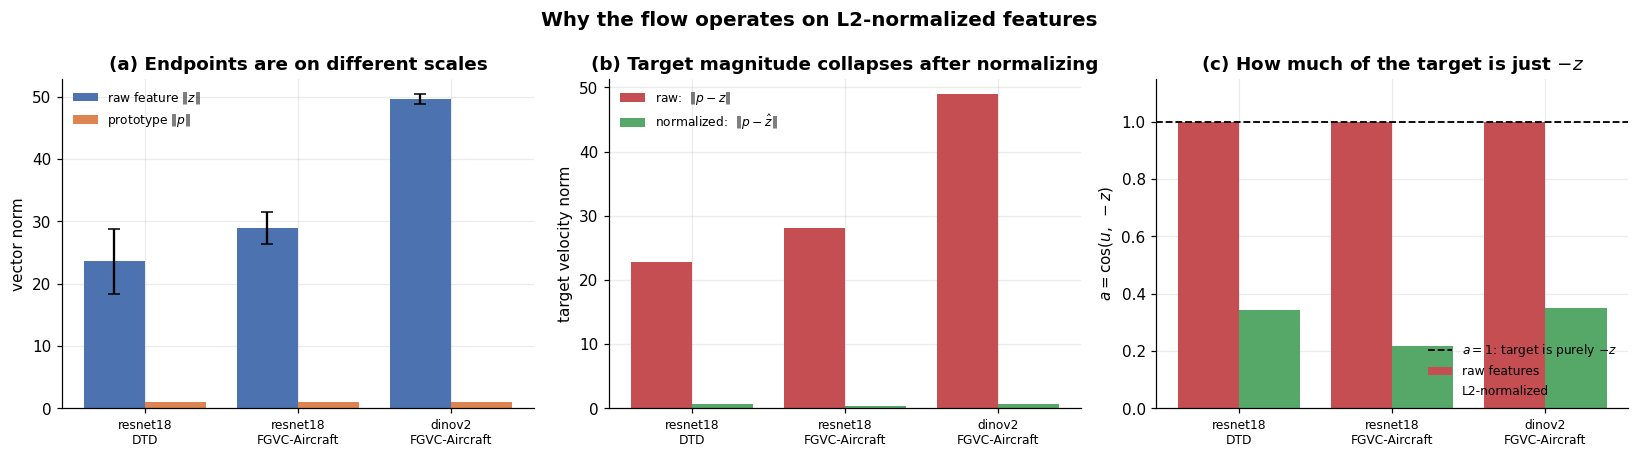

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
labels = [f"{e}\n{d}" for e, d in COMBOS]
x = np.arange(len(COMBOS))

# (a) the scale mismatch itself
ax = axes[0]
ax.bar(x - 0.2, geometry.feat_norm_raw_mean, 0.4, yerr=geometry.feat_norm_raw_std,
       capsize=4, color="#4C72B0", label="raw feature $\\|z\\|$")
ax.bar(x + 0.2, geometry.proto_norm, 0.4, color="#DD8452", label="prototype $\\|p\\|$")
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("vector norm")
ax.set_title("(a) Endpoints are on different scales")
ax.legend(fontsize=8)

# (b) what the flow target actually looks like
ax = axes[1]
ax.bar(x - 0.2, geometry.target_norm_raw, 0.4, color="#C44E52", label="raw:  $\\|p - z\\|$")
ax.bar(x + 0.2, geometry.target_norm_norm, 0.4, color="#55A868",
       label="normalized:  $\\|p - \\hat z\\|$")
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("target velocity norm")
ax.set_title("(b) Target magnitude collapses after normalizing")
ax.legend(fontsize=8)

# (c) the diagnostic that motivates the decision
ax = axes[2]
ax.bar(x - 0.2, geometry.align_raw, 0.4, color="#C44E52", label="raw features")
ax.bar(x + 0.2, geometry.align_normalized, 0.4, color="#55A868", label="L2-normalized")
ax.axhline(1.0, color="black", ls="--", lw=1.2,
           label=r"$a = 1$: target is purely $-z$")
ax.set_ylim(0, 1.15)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel(r"$a = \cos(u,\; -z)$")
ax.set_title(r"(c) How much of the target is just $-z$")
ax.legend(fontsize=8, loc="lower right")

fig.suptitle("Why the flow operates on L2-normalized features", fontsize=13, fontweight="bold")
fig.tight_layout()
art.figure(fig, "feature_norm_mismatch")
plt.show()

**Reading (c):** with raw features the alignment $a = \cos(u, -z)$ sits at essentially
**1.00** — the "move to your prototype" target is numerically almost identical to "cancel
your own feature", which carries no class information whatsoever. After normalization $a$
drops well below 1, meaning the prototype term genuinely shapes the direction the network is
asked to predict.

Panels (a) and (b) show the mechanism behind that number: the two endpoints differ in scale
by a factor of ~24–50, so the target norm $\lVert p - z \rVert$ is almost exactly
$\lVert z \rVert$ — the prototype is lost in the rounding. Normalizing collapses the target
to a well-conditioned magnitude below 1.

Every subsequent step therefore works on $\hat z = z / \lVert z \rVert$.

## 4 · Build the prototypes

One prototype set per `(encoder, dataset, K, seed)`, using the **same** `make_kshot_subset`
Stage 1 used — for a given `(K, seed)` the subset contains exactly the same images, which is
what makes the Stage 2 numbers directly comparable to the Stage 1 baseline.

**Why 21 sets and not 27.** For $K \in \{5, 10\}$ the seed selects *which images* form the
subset, so all three seeds give different prototypes: $3 \times 2 \times 3 = 18$. For
$K = \text{full}$ there is nothing left to subsample and prototype computation is
deterministic, so there is exactly **one** prototype set per combination: $+3 = 21$.

This matters later: FM training at $K = \text{full}$ still runs three seeds, but the seed
varies only the *network* initialisation and batch order — all three share these same
prototypes as their targets.

In [7]:
def proto_key(encoder: str, dataset: str, K, seed) -> str:
    '''Canonical key for one prototype set. `seed=None` marks the deterministic full-data
    case, so the key stays unambiguous when FM later runs three seeds against it.'''
    tag = "NA" if seed is None else str(seed)
    return f"{encoder}__{dataset}__K{K}__seed{tag}"


RUNS: list[tuple[str, str, object, object]] = []
for enc, ds in COMBOS:
    for K in K_SETTINGS:
        if K == "full":
            RUNS.append((enc, ds, K, None))
        else:
            RUNS.extend((enc, ds, K, seed) for seed in SEEDS)

print(f"{len(RUNS)} prototype sets to build")

21 prototype sets to build


In [8]:
prototypes: dict[str, torch.Tensor] = {}
grid_rows: list[dict] = []

build_start = time.perf_counter()
for enc, ds, K, seed in RUNS:
    tr = features[(enc, ds, "train")]

    if K == "full":
        sub_x, sub_y = tr.features, tr.labels
    else:
        sub_x, sub_y = make_kshot_subset(tr.features, tr.labels, k=K, seed=seed)

    protos = compute_prototypes(sub_x, sub_y, tr.n_classes)
    key = proto_key(enc, ds, K, seed)
    prototypes[key] = protos

    grid_rows.append({
        "key": key,
        "encoder": enc,
        "dataset": ds,
        "K": str(K),
        "seed": "NA" if seed is None else seed,
        "n_train": int(sub_x.shape[0]),
        "n_classes": tr.n_classes,
        "dim": tr.dim,
        "proto_norm_min": round(protos.norm(dim=1).min().item(), 6),
        "proto_norm_max": round(protos.norm(dim=1).max().item(), 6),
    })

run_grid = pd.DataFrame(grid_rows)
print(f"built {len(prototypes)} prototype sets in {time.perf_counter() - build_start:.2f}s")

# Every prototype must be exactly unit-norm - this is the invariant the flow target relies on.
assert np.allclose(run_grid.proto_norm_min, 1.0, atol=1e-5), "a prototype is not unit-norm"
assert np.allclose(run_grid.proto_norm_max, 1.0, atol=1e-5), "a prototype is not unit-norm"
print("all prototypes are unit-norm")

art.table(run_grid, "run_grid")
run_grid

built 21 prototype sets in 0.21s
all prototypes are unit-norm
  saved table -> tables/run_grid.csv  (21 rows)


,key,encoder,dataset,K,seed,n_train,n_classes,dim,proto_norm_min,proto_norm_max
0,resnet18__DTD__K5__seed0,resnet18,DTD,5,0,235,47,512,1.0,1.0
1,resnet18__DTD__K5__seed1,resnet18,DTD,5,1,235,47,512,1.0,1.0
2,resnet18__DTD__K5__seed2,resnet18,DTD,5,2,235,47,512,1.0,1.0
3,resnet18__DTD__K10__seed0,resnet18,DTD,10,0,470,47,512,1.0,1.0
4,resnet18__DTD__K10__seed1,resnet18,DTD,10,1,470,47,512,1.0,1.0
5,resnet18__DTD__K10__seed2,resnet18,DTD,10,2,470,47,512,1.0,1.0
6,resnet18__DTD__Kfull__seedNA,resnet18,DTD,full,NA,1880,47,512,1.0,1.0
7,resnet18__FGVC-Aircraft__K5__seed0,resnet18,FGVC-Aircraft,5,0,500,100,512,1.0,1.0
8,resnet18__FGVC-Aircraft__K5__seed1,resnet18,FGVC-Aircraft,5,1,500,100,512,1.0,1.0
9,resnet18__FGVC-Aircraft__K5__seed2,resnet18,FGVC-Aircraft,5,2,500,100,512,1.0,1.0


## 5 · Verification against Stage 1

The check that makes everything after this trustworthy: classify the **full official test
split** with each prototype set using Stage 1's own `run_prototype_classifier`, and compare
against the accuracies Stage 1 recorded in `results/prototype_runs.csv`.

Because prototype computation and the cosine rule are both deterministic, this is an **exact**
check — not a within-noise comparison. Any non-zero difference means the subsets or the
feature cache have drifted, and Stage 2 must not proceed.

In [9]:
stage1 = pd.read_csv(STAGE1_RESULTS / "prototype_runs.csv")
stage1["seed_key"] = stage1["seed"].apply(lambda s: "NA" if pd.isna(s) else str(int(s)))
stage1["K"] = stage1["K"].astype(str)
print(f"Stage 1 recorded {len(stage1)} prototype runs")
stage1.head()

Stage 1 recorded 21 prototype runs


,encoder,dataset,K,seed,n_train,test_acc,elapsed_s,seed_key
0,resnet18,DTD,5,0.0,235,0.469149,0.009315,0
1,resnet18,DTD,5,1.0,235,0.439362,0.008291,1
2,resnet18,DTD,5,2.0,235,0.474468,0.007398,2
3,resnet18,DTD,10,0.0,470,0.507447,0.010536,0
4,resnet18,DTD,10,1.0,470,0.531915,0.006399,1


In [10]:
verify_rows: list[dict] = []

for enc, ds, K, seed in RUNS:
    tr = features[(enc, ds, "train")]
    te = features[(enc, ds, "test")]

    if K == "full":
        sub_x, sub_y = tr.features, tr.labels
    else:
        sub_x, sub_y = make_kshot_subset(tr.features, tr.labels, k=K, seed=seed)

    # Stage 1's own function, unmodified - it normalizes internally, so passing raw
    # features here reproduces the baseline exactly.
    result = run_prototype_classifier(sub_x, sub_y, te.features, te.labels, tr.n_classes)

    seed_key = "NA" if seed is None else str(seed)
    match = stage1[(stage1.encoder == enc) & (stage1.dataset == ds)
                   & (stage1.K == str(K)) & (stage1.seed_key == seed_key)]
    assert len(match) == 1, f"expected exactly one Stage 1 row for {enc}/{ds}/K={K}/seed={seed}"

    ours = 100 * result.test_acc
    theirs = 100 * float(match["test_acc"].iloc[0])
    verify_rows.append({
        "encoder": enc, "dataset": ds, "K": str(K), "seed": seed_key,
        "stage1_acc": round(theirs, 4),
        "stage2_recomputed": round(ours, 4),
        "delta_pp": round(ours - theirs, 10),
    })

verification = pd.DataFrame(verify_rows)
max_delta = verification.delta_pp.abs().max()
print(f"max |delta| across {len(verification)} runs: {max_delta:.2e} pp")
assert max_delta < 1e-6, "Stage 2 does NOT reproduce the Stage 1 baseline - stop here"
print("EXACT MATCH - the Stage 1 prototype baseline is reproduced on all 21 runs")

art.table(verification, "prototype_verification")
verification

max |delta| across 21 runs: 0.00e+00 pp
EXACT MATCH - the Stage 1 prototype baseline is reproduced on all 21 runs
  saved table -> tables/prototype_verification.csv  (21 rows)


,encoder,dataset,K,seed,stage1_acc,stage2_recomputed,delta_pp
0,resnet18,DTD,5,0,46.9149,46.9149,0.0
1,resnet18,DTD,5,1,43.9362,43.9362,0.0
2,resnet18,DTD,5,2,47.4468,47.4468,0.0
3,resnet18,DTD,10,0,50.7447,50.7447,0.0
4,resnet18,DTD,10,1,53.1915,53.1915,0.0
5,resnet18,DTD,10,2,51.0638,51.0638,0.0
6,resnet18,DTD,full,NA,58.8298,58.8298,0.0
7,resnet18,FGVC-Aircraft,5,0,16.5917,16.5917,0.0
8,resnet18,FGVC-Aircraft,5,1,16.0216,16.0216,0.0
9,resnet18,FGVC-Aircraft,5,2,16.7717,16.7717,0.0


  saved plot  -> plots/baseline_reproduction.png


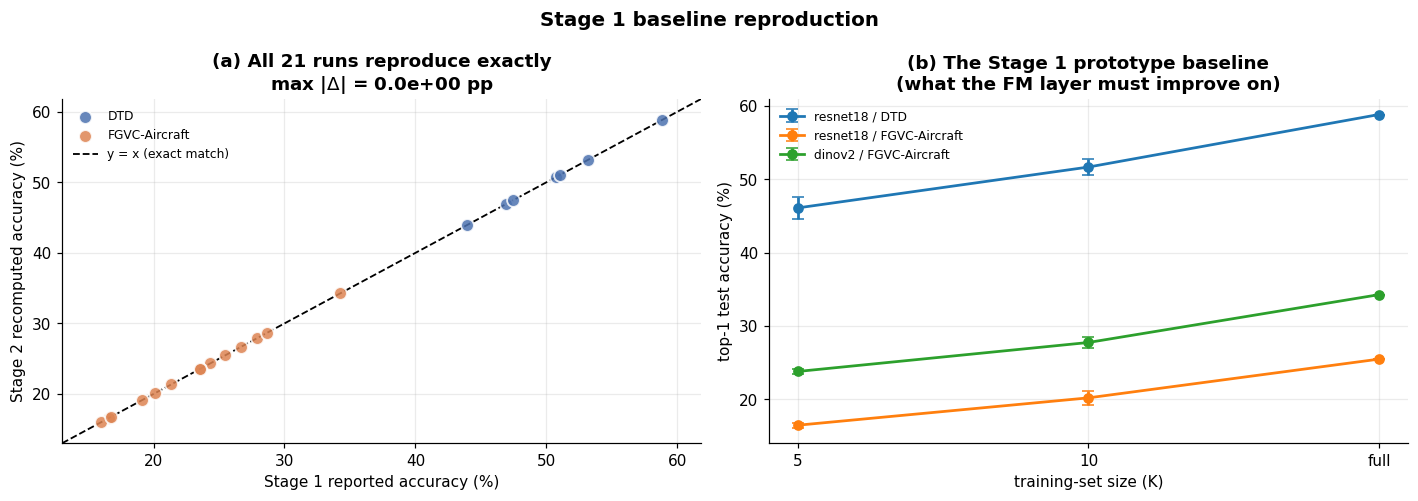

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# (a) identity check across all 21 runs
ax = axes[0]
colors = {"DTD": "#4C72B0", "FGVC-Aircraft": "#DD8452"}
for ds, grp in verification.groupby("dataset"):
    ax.scatter(grp.stage1_acc, grp.stage2_recomputed, s=70, alpha=0.85,
               color=colors[ds], edgecolor="white", linewidth=1.2, label=ds, zorder=3)
lims = [verification.stage1_acc.min() - 3, verification.stage1_acc.max() + 3]
ax.plot(lims, lims, ls="--", color="black", lw=1.2, label="y = x (exact match)", zorder=2)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Stage 1 reported accuracy (%)")
ax.set_ylabel("Stage 2 recomputed accuracy (%)")
ax.set_title(f"(a) All 21 runs reproduce exactly\nmax |$\\Delta$| = {max_delta:.1e} pp")
ax.legend(fontsize=8)

# (b) the baseline Stage 2 has to beat
ax = axes[1]
order = ["5", "10", "full"]
for (enc, ds), grp in verification.groupby(["encoder", "dataset"], sort=False):
    means = [grp[grp.K == k].stage2_recomputed.mean() for k in order]
    errs = [grp[grp.K == k].stage2_recomputed.std(ddof=0) if len(grp[grp.K == k]) > 1 else 0.0
            for k in order]
    ax.errorbar(order, means, yerr=errs, marker="o", capsize=4, lw=1.8, label=f"{enc} / {ds}")
ax.set_xlabel("training-set size (K)")
ax.set_ylabel("top-1 test accuracy (%)")
ax.set_title("(b) The Stage 1 prototype baseline\n(what the FM layer must improve on)")
ax.legend(fontsize=8)

fig.suptitle("Stage 1 baseline reproduction", fontsize=13, fontweight="bold")
fig.tight_layout()
art.figure(fig, "baseline_reproduction")
plt.show()

## 6 · Save Stage 2 artefacts

Only the prototypes are saved. The k-shot subsets are **not** — they are regenerated on
demand by `make_kshot_subset(features, labels, k, seed)`, which is deterministic, so caching
them would add a second source of truth that could silently drift from Stage 1's.

In [12]:
payload = {
    "prototypes": prototypes,
    "meta": {
        "created_by": "Stage 2, step 01_setup_prototypes",
        "n_sets": len(prototypes),
        "combos": COMBOS,
        "k_settings": [str(k) for k in K_SETTINGS],
        "seeds": SEEDS,
        "key_format": "{encoder}__{dataset}__K{K}__seed{seed|NA}",
        "unit_norm": True,
        "verified_against": "Stage_1/results/prototype_runs.csv (exact, max |delta| "
                            f"= {max_delta:.2e} pp)",
        "note": "Full-data sets carry seed=NA: prototypes there are deterministic, so all "
                "three FM seeds share one target set.",
    },
}
out_path = RESULTS_ROOT / "prototypes.pt"
torch.save(payload, out_path)
print(f"saved -> results/{out_path.name}  ({out_path.stat().st_size / 1024:.1f} KB, "
      f"{len(prototypes)} sets)")

methodology = pd.DataFrame([
    {"item": "prototype rule", "value": "mu_c = normalize(mean_i normalize(z_i))  [cvlab.prototypes]"},
    {"item": "classification rule", "value": "argmax_c cos(z, mu_c)  - unchanged from Stage 1"},
    {"item": "k-shot subsets", "value": "cvlab.data.make_kshot_subset - the same function Stage 1 used"},
    {"item": "flow input", "value": "L2-normalized features (see section 3)"},
    {"item": "prototype sets", "value": f"{len(prototypes)} (18 subsampled + 3 deterministic full-data)"},
    {"item": "baseline check", "value": f"exact match on all {len(verification)} runs"},
    {"item": "encoders run", "value": "none - Stage 1 feature cache read only"},
])
art.table(methodology, "methodology")
methodology

saved -> results/prototypes.pt  (3115.3 KB, 21 sets)
  saved table -> tables/methodology.csv  (7 rows)


,item,value
0,prototype rule,mu_c = normalize(mean_i normalize(z_i)) [cvla...
1,classification rule,"argmax_c cos(z, mu_c) - unchanged from Stage 1"
2,k-shot subsets,cvlab.data.make_kshot_subset - the same functi...
3,flow input,L2-normalized features (see section 3)
4,prototype sets,21 (18 subsampled + 3 deterministic full-data)
5,baseline check,exact match on all 21 runs
6,encoders run,none - Stage 1 feature cache read only


## 7 · Manifest

In [13]:
art.manifest()
print()
print("Shared artefact for steps 2-5:")
print(f"  results/prototypes.pt   {out_path.stat().st_size / 1024:8.1f} KB")

8 artefacts in C:\Users\youse\Project in Computer Vision\ProjectInComputerVision\Stage_2\Work\01_setup_prototypes

Shared artefact for steps 2-5:
  results/prototypes.pt     3115.3 KB


---

## Next step

**Step 2 — Standard FM training.** Implements the velocity network $v_\theta(z, t)$ and the
standard flow-matching objective

$$\mathcal{L}_\mathrm{FM} = \lVert v_\theta(z_t, t) - u_i \rVert_2^2,
\qquad z_t = (1-t)\hat z_i + t\,p_{y_i}, \qquad u_i = p_{y_i} - \hat z_i$$

trained on the L2-normalized features and the prototypes saved above. One model per
`(combination, K, seed)` — 27 models — each evaluated at both $T = 4$ and $T = 12$, since
standard FM training does not depend on the number of inference steps.